In [326]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

pd.pandas.set_option('display.max_columns',None)
#Importing and loading the dataset
df = pd.read_csv(r'c:\Users\DELL\Downloads\loan_data.csv')
print(df.shape)

(45000, 5)


In [327]:
df.head()

,Age,Income,LoanAmount,CreditScore,Approved
0,22,71948,35000,561,1
1,21,12282,1000,504,0
2,25,12438,5500,635,1
3,23,79753,35000,675,1
4,24,66135,35000,586,1


In [328]:
#Data Set info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Age          45000 non-null  int64
 1   Income       45000 non-null  int64
 2   LoanAmount   45000 non-null  int64
 3   CreditScore  45000 non-null  int64
 4   Approved     45000 non-null  int64
dtypes: int64(5)
memory usage: 1.7 MB


In [329]:
#Checking the missing values
df.isnull().sum()


Age            0
Income         0
LoanAmount     0
CreditScore    0
Approved       0
dtype: int64

In [330]:
#first we will find the missing values in the loanamount and creditamount
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())

In [331]:
df['CreditScore'] = df['CreditScore'].fillna(df['CreditScore'].mean())

In [332]:
#Checking for null values in loan amount and creditamount
df.isnull().sum()

Age            0
Income         0
LoanAmount     0
CreditScore    0
Approved       0
dtype: int64

In [333]:
#Drop all the missing values
df.dropna(inplace = True)

In [334]:
#checking the missing values for the last time
df.isnull().sum()

Age            0
Income         0
LoanAmount     0
CreditScore    0
Approved       0
dtype: int64

In [335]:
df['Age'].fillna(df['Age'].mean(),inplace= True)
df['Income'].fillna(df['Income'].mean(),inplace= True)
df['LoanAmount'].fillna(df['LoanAmount'].mean(),inplace= True)
df['CreditScore'].fillna(df['CreditScore'].mean(),inplace= True)

0        561
1        504
2        635
3        675
4        586
        ... 
44995    645
44996    621
44997    668
44998    604
44999    628
Name: CreditScore, Length: 45000, dtype: int64

In [336]:
df.isnull().sum()

Age            0
Income         0
LoanAmount     0
CreditScore    0
Approved       0
dtype: int64

In [337]:
#final dataset shape
df.shape

(45000, 5)

EDA

<Axes: xlabel='Approved', ylabel='CreditScore'>

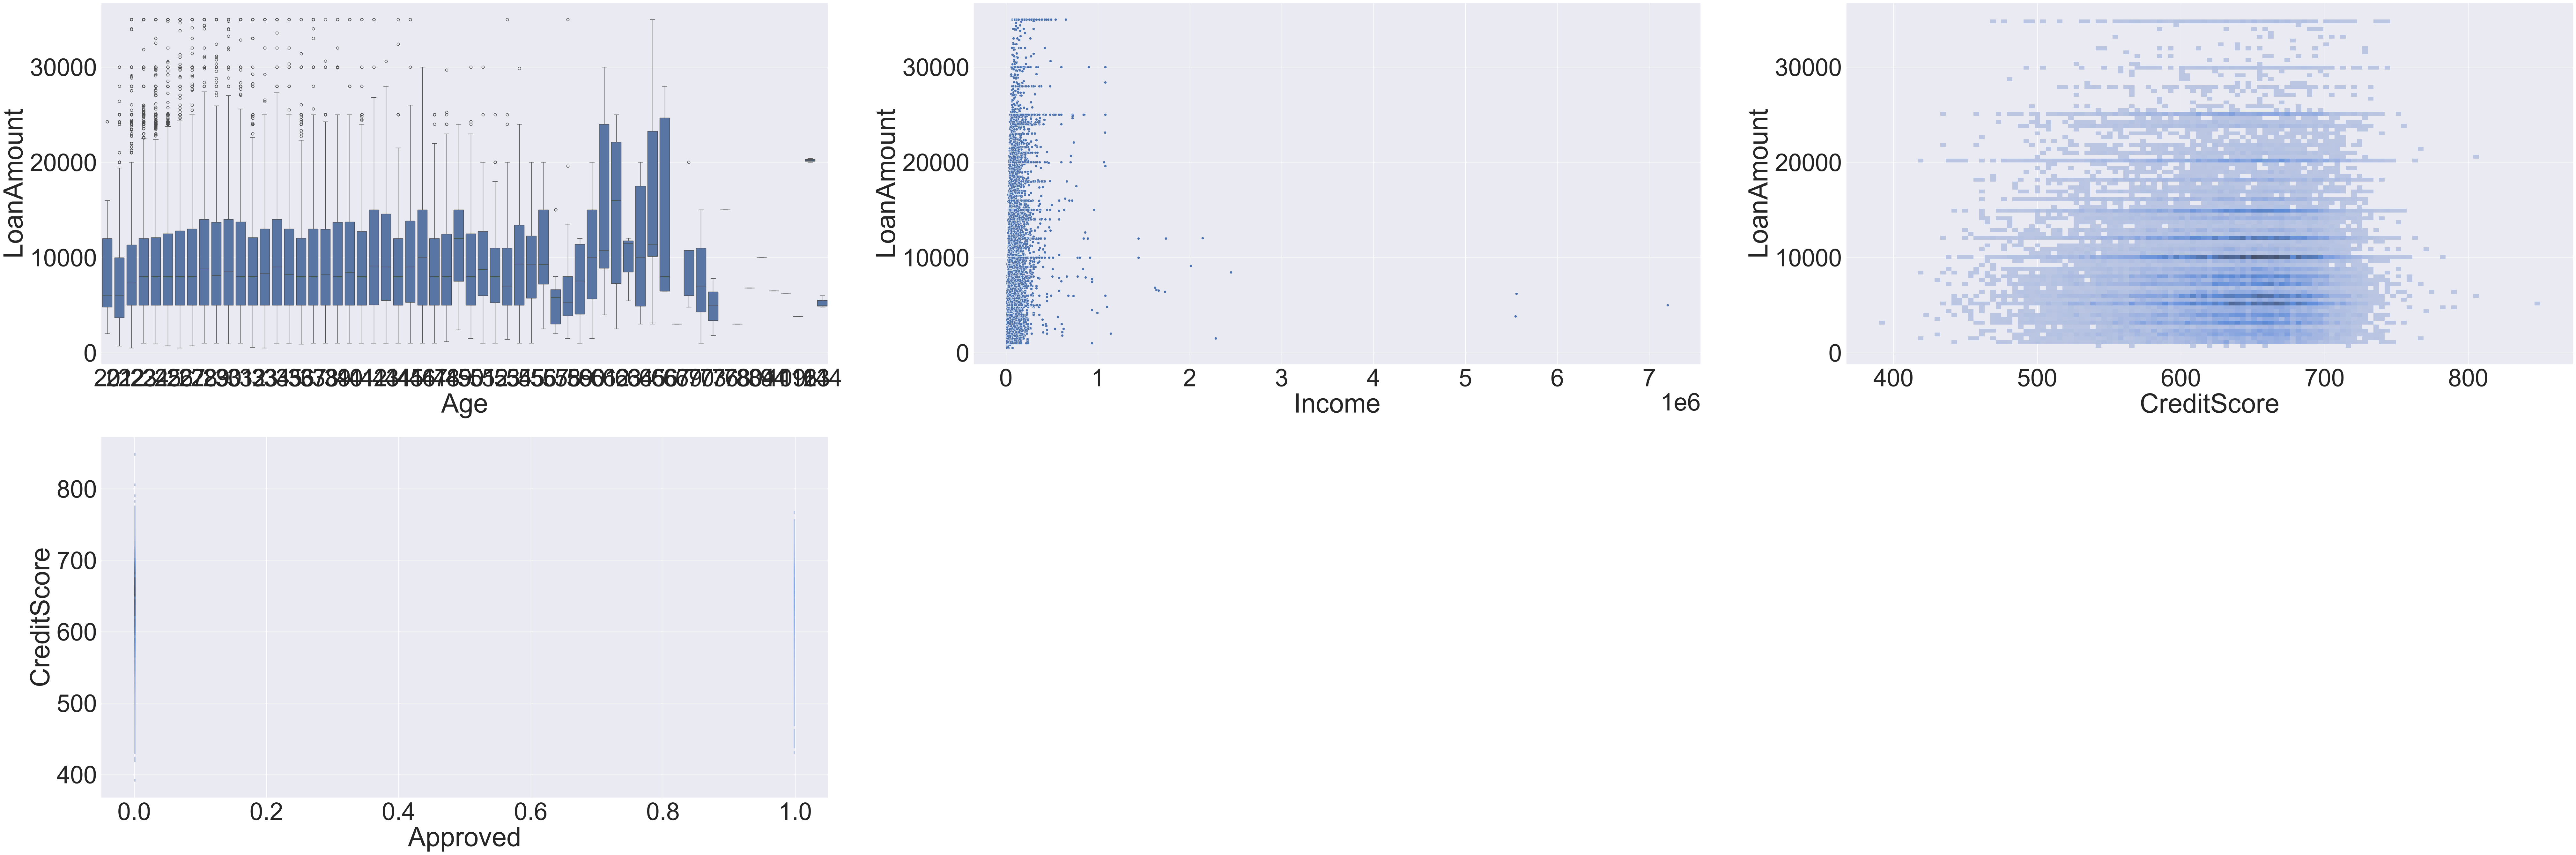

In [338]:
#Exploratory Data Analysis
#Comparison made using a graph
plt.figure(figsize=(100,50))
sns.set(font_scale = 5)
plt.subplot(331)
sns.boxplot(data = df ,x ='Age', y = 'LoanAmount')
plt.subplot(332)
sns.scatterplot(data = df ,x='Income', y ='LoanAmount')
plt.subplot(333)
sns.histplot(data = df , x = 'CreditScore' , y = 'LoanAmount')
plt.subplot(334)
sns.histplot(data = df, x = 'Approved', y = 'CreditScore')

In [339]:
#Feature and Target Selection
X = df.drop("Approved", axis = 1) #independent 
y = df["Approved"]                #dependent

In [340]:
from sklearn.model_selection import train_test_split

X_test , X_train , y_test , y_train = train_test_split(X,y,test_size=0.2, random_state= 42) 

In [341]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [342]:
#Prediction
pred = model.predict(X_test)
y_pred = model.predict(X_test)

In [343]:
#Accuracy
from sklearn.metrics import accuracy_score
print("Accuracy :", accuracy_score(y_test,y_pred))

Accuracy : 0.76225


In [344]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
print("confusion:", confusion_matrix(y_test,y_pred))

confusion: [[23573  4437]
 [ 4122  3868]]


In [345]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85     28010
           1       0.47      0.48      0.47      7990

    accuracy                           0.76     36000
   macro avg       0.66      0.66      0.66     36000
weighted avg       0.77      0.76      0.76     36000



In [346]:
import joblib

joblib.dump(model, "loan_model.pkl")

['loan_model.pkl']